**Overview.**

In this year’s WiDS Global Datathon, your challenge is to help answer these tough questions. Using only the data from the first five hours after a fire begins, you’ll build models that predict the chances of a wildfire threatening an evacuation zone within 12, 24, 48, and 72 hours.

Rather than making just one prediction, the goal is to provide reliable probability estimates across these different time frames. This helps emergency responders not only prioritize which fires need immediate attention, but also make informed decisions about evacuations, resource planning, and public safety alerts.


**Description.**

**Problem:**
When a wildfire starts, emergency teams need to make important decisions very quickly. They must decide which communities to warn, when to send alerts, and where to send limited resources like firefighters and aircraft.
The challenge is that these decisions have to be made before they are certain about what will happen.

**So they need two key things:**


*   Prioritization → Which fires are most urgent right now
*   Risk estimates → How likely a fire is to become dangerous within a certain time.

In this competition, you’ll help solve this problem by building models that predict these risks over time.





In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import Markdown

In [ ]:
# Detect environment and load data accordingly
try:
    # Check if running in Google Colab
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in Jupyter Notebook")

# Mount Google Drive and load data if in Colab
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    
    # Load data from Google Drive
    df_train = pd.read_csv('/content/drive/MyDrive/W in Data/Datathon/WiDSWorldWide_GlobalDathon26/train.csv')
    df_test = pd.read_csv('/content/drive/MyDrive/W in Data/Datathon/WiDSWorldWide_GlobalDathon26/test.csv')
    data_dict = pd.read_csv('/content/drive/MyDrive/W in Data/Datathon/WiDSWorldWide_GlobalDathon26/metaData.csv')
else:
    # Load data from local data folder
    df_train = pd.read_csv('./data/train.csv')
    df_test = pd.read_csv('./data/test.csv')
    data_dict = pd.read_csv('./data/metaData.csv')

print(f"\nData loaded successfully!")
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Metadata shape: {data_dict.shape}")

# Data Understanding

Features computed strictly from the first five hours after initial perimeter detection. These represent early spread dynamics and spatial relationships to evacuation zones.

**Dataset Overview**

**Data Limitations and Scarcity**
This page describes the data, provided files, their formats, and the required submission format.

The dataset contains 316 wildfire events with verified early-stage perimeter observations and confirmed outcomes.

**What you receive**
Features computed strictly from the first five hours after initial perimeter detection. These represent early spread dynamics and spatial relationships to evacuation zones.

**What you predict**
Four probabilities for each fire. Each probability represents the likelihood that the fire comes within 5 km of an evacuation zone centroid by the horizon. prob_12h prob_24h prob_48h prob_72h


**Lets diplay the data set with display.max_colwidt.  With this setting, you can see the full description or full sentence inside the cell.**







In [ ]:
#This line is used in pandas (Python) to change how data is shown.
pd.set_option('display.max_colwidth', None)
data_dict

In the data set we have 36 columns in total. 2 coulms  are out traget varables named as event and time_to_hit_hours. Other features act as the predictors of the target.

Target:
*   We have 2 target variables (Represents whether a wildfire reaches an evacuation zone within 72 hours and the time it takes to reach it (if it occurs), used to model survival and risk over time.)

Predictors:

*   Temporal coverage: 3 (Describes how the fire was observed and recorded over the first five hours, including data frequency and reliability.)
*   Growth: 10 (Captures how the fire increases in size over time, including area expansion and growth rate.)
*   Centroid kinematics: 5 (Describes the movement of the fire’s center, including its speed and direction of spread.)
*   Distance: 9 (Measures how far the fire is from evacuation zones and whether it is moving closer or farther away.)
*   Directionality: 4 (Captures whether the fire’s movement is aligned toward or away from evacuation zones.)
*  Temporal metadata: 3 (Provides information about when the fire started, including hour, day, and month.)














## Train and Test Sets Observation.
Now let’s look at the training and test sets.

In machine learning, the dataset is typically split into two parts: a training set and a test set. This is done to ensure that the model learns underlying patterns in the data rather than simply memorizing it.

The training set, which usually makes up around 70–80% of the data, is used to train the model. The test set, which is typically 20–30%, is used to evaluate the model’s performance on unseen data.

This separation helps us check how well the model generalizes and how accurately it can make predictions on new data.

We will use the` head()` function to display the first few rows of both tables, which helps us quickly understand what the data looks like. We will also use the `shape` function to find out how many rows and columns each table contains.”






In [ ]:
df_train.head()

In [ ]:
df_test.head()

In [ ]:
print("The train set's shape: ",df_train.shape[0], "rows and", df_train.shape[1], "columns.", '\n')
print("The test set's shape: ",df_test.shape[0], "rows and", df_test.shape[1], "columns.")

**Data set size**

*   Train test - 221 fiers
*   Test set - 95 fires
*   Total- 361 fires





## Data Types and Missing Values.

It is very important, before starting any analysis, to understand the type of data we are working with and to check for missing values. Missing values can affect the quality of the analysis, so they need to be identified and properly handled.

I will use the `info()` function to understand the data types and check for missing values in the dataset.”

In [ ]:
# Summary info
print("df_train info:")
df_train.info()

print("\ndf_test info:")
df_test.info()

All features in both datasets are fully complete, with no missing values, and they are mostly numerical, consisting of both float and integer types.

Overall, this confirms that the data is clean, well-structured, and ready for further exploratory data analysis and modeling.

I also checked the data quality by using the `isnull().sum() `function to identify missing values and the `duplicated().sum()` function to detect duplicate rows. The results show that there are no missing values and no duplicates in either dataset, so the data is clean and ready for analysis

In [ ]:
# Total null values in each dataframe
print("Total nulls in df_train:", df_train.isnull().sum().sum())
print("Total nulls in df_test:", df_test.isnull().sum().sum())
print()
print("Total train duplicate rows:", df_train.duplicated().sum())
print("Total test duplicate rows:", df_test.duplicated().sum())

The results show that there are no missing values and no duplicate rows in either dataset.

This confirms that the data is complete, clean, and consistent, and therefore suitable for further analysis and modeling.



**Targets (training only)**

**event:**

1 → Fire reached an evacuation zone within 72h

0 → Fire did NOT reach (censored case)

**time_to_hit_hours:** Time (in hours) from 5 hours after the fire starts until it gets within 5 km of an evacuation zone. If the fire never gets close within 72 hours, this shows the last time we observed it (up to 72h).   





**Event Distribution**

Visualising the event distribution helps us understand how often fires reach evacuation zones and whether the data is balanced. It shows that most fires are censored (they do not reach an evacuation zone within 72 hours), while a smaller portion result in a hit event. This imbalance is important because it can cause models to become biased toward the majority class, leading to misleading performance if not handled properly.

In addition, the distribution reflects real-world behaviour: most fires do not escalate to threaten evacuation zones, while only a few become dangerous. It also highlights that censored observations are not true negatives, but cases where the event was simply not observed within the time window. This reinforces that the problem should be treated as a survival analysis task rather than a standard classification problem.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style
sns.set_style("whitegrid")

colors = ['#A0AEC0', '#E76F51']  # soft gray-blue, muted orange-red
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x='event',
    data=df_train,
    hue='event',
    palette=colors,
    order=[0, 1],
    hue_order=[0, 1],
    legend=False
)

# Add labels (count + percentage)
total = len(df_train)

for container in ax.containers:
    labels = [
        f'{int(val):,}\n({(val/total)*100:.1f}%)'
        for val in container.datavalues
    ]
    ax.bar_label(container, labels=labels, fontsize=11, fontweight='bold')

# Improve axis labels
ax.set_xticklabels(['Censored (0).', 'Fire Hit Within 72 hr (1)'])

# Titles
plt.title('Fire Outcomes: Event vs Censored',
          fontsize=14, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Number of Fires')

# Add slight headroom
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

The majority of fires 152 (≈68.8%) are censored and do not reach evacuation zones within 72 hours, while only a smaller portion of 69 fires (≈31.2%) result in a hit event. This indicates a clear class imbalance and reflects real-world wildfire behavior, where most fires are contained or do not threaten evacuation zones.

**Time to hit hours Distribution**


Our target variable is tricky. We have fires that hit the evacuation zone within 72 hours, which are recorded as events (event = 1).

We also have fires that did not reach the evacuation zone within 72 hours, but for which we do not know the exact outcome — these are censored observations (event = 0).

It is important to note that even among the censored observations (event = 0), some fires may have been observed before the 72-hour window, while others were never recorded. Similarly, some fires that did reach the evacuation zone may also not have been tracked within the 72-hour window.

In other words, our target is partially observed and partially censored, which makes this a classic scenario for survival analysis, where we model the time-to-event while accounting for censored and incomplete observations.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter hits and censored fires
hit_times = df_train.loc[df_train['event'] == 1, 'time_to_hit_hours']
censored_times = df_train.loc[df_train['event'] == 0, 'time_to_hit_hours']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ---- Hits histogram ----
sns.histplot(
    hit_times,
    bins=30,
    color='#D55E00',  # orange for hits
    alpha=0.7,
    edgecolor='white',
    ax=axes[0]
)
# Add median line for hits only
axes[0].axvline(hit_times.median(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Median: {hit_times.median():.1f}h')
# Add censoring limit
axes[0].axvline(72, color='gray', linestyle=':', linewidth=2, label='Censoring limit')
axes[0].set_title('Hits Only')
axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Number of Fires')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Censored histogram ----
sns.histplot(
    censored_times,
    bins=30,
    color='#0072B2',  # blue for censored
    alpha=0.7,
    edgecolor='white',
    ax=axes[1]
)
# Add censoring limit
axes[1].axvline(72, color='gray', linestyle=':', linewidth=2, label='Censoring limit')
axes[1].set_title('Censored Only')
axes[1].set_xlabel('Time (hours)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Distribution of Time to Hit Evacuation Zone', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# Filter only fires that hit
hit_times = df_train.loc[df_train['event'] == 1, 'time_to_hit_hours']

# Print simplified hit time summary
print("=" * 60)
print("HIT FIRE TIME STATISTICAL SUMMARY")
print("=" * 60)
print(f"Average time to hit: {hit_times.mean():.1f} hours")
print(f"Median time to hit:  {hit_times.median():.1f} hours")
print(f"Fastest hit fire:    {hit_times.min():.2f} hours")
print(f"Slowest hit fire:    {hit_times.max():.1f} hours")
print("=" * 60)

Average time to hit: 10.0 hours — on average, fires reach the evacuation zone
in about 10 hours.

Median time to hit: 3.5 hours — half of the fires hit within 3.5 hours, showing that most dangerous fires escalate very quickly.

Fastest hit fire: 0.00 hours — the quickest fire reached the zone almost immediately.

Slowest hit fire: 66.9 hours — some fires took much longer to reach the zone, creating a right-skewed distribution.

Most fires that reach the evacuation zone do so very quickly, often within just a few hours. While some fires take longer, the majority spread fast, showing how important it is to detect and respond to dangerous fires as early as possible.



**Distance**

The distance of a fire from the evacuation zone is a very important factor. Fires that are closer to the evacuation zone are more dangerous because they are more likely to reach it quickly. We analysed the distance of each fire from the nearest evacuation zone and visualised it with a 10 km threshold


In [ ]:
import matplotlib.pyplot as plt

# ---- Define colors for hits and censored ----
HIT_COLOR = '#D55E00'  # orange for hits
MISS_COLOR = '#0072B2'  # blue for censored
FIRE_COLORS = ['#56B4E9', '#009E73', '#F0E442']  # Color palette for threshold

# ---- Distance distribution histogram only ----
plt.figure(figsize=(10, 5))

# Plot for "Hit" and "Censored" categories
for label, color, mask in [
    ('Hit', HIT_COLOR, df_train['event'] == 1),
    ('Censored', MISS_COLOR, df_train['event'] == 0)
]:
    # Convert meters to kilometers for readability
    km = df_train.loc[mask, 'dist_min_ci_0_5h'] / 1000
    plt.hist(km, bins=30, alpha=0.55, color=color, label=label, edgecolor='none')

# Mark the 10 km threshold
plt.axvline(10, color=FIRE_COLORS[2], ls='--', lw=2, label='10 km threshold')

# Set titles and labels
plt.title('Distance to Nearest Evacuation Zone')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Fires')
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

# Print statistics
hit_dist = df_train.loc[df_train['event'] == 1, 'dist_min_ci_0_5h']
miss_dist = df_train.loc[df_train['event'] == 0, 'dist_min_ci_0_5h']

print("Distance Statistics:")
print(f"  Fires that HIT:      avg {hit_dist.mean()/1000:.1f} km, max {hit_dist.max()/1000:.1f} km")
print(f"  Fires that MISSED:   avg {miss_dist.mean()/1000:.1f} km, max {miss_dist.max()/1000:.1f} km")
print(f"Critical finding: {(hit_dist > 10000).sum()} fires beyond 10 km ever hit!")
print("This tells us distance is incredibly predictive.")

In our data, we tracked fires over 72 hours:

“Hit” fires are those that reached the evacuation zone within that time. These fires were almost all very close to the zone (average 2.3 km, maximum 4.7 km).

“Censored” fires are fires that either didn’t reach the zone or were not observed in time. These fires were mostly much farther away (average 179.8 km, maximum 757.7 km).



Most “Hit” fires (orange) are clustered very close to the evacuation zone, mostly within 10 km.
“No-hit” fires (blue) tend to be farther away, often hundreds of kilometers away from any evacuation zone.
The 10 km gate line clearly shows the critical threshold: fires closer than this are much more likely to hit.

Distance is an extremely strong predictor of whether a fire will reach an evacuation zone. This simple threshold (10 km) effectively separates high-risk fires from low-risk ones, helping prioritize monitoring and response efforts.



**To understand the statistical properties of our dataset, we used the describe() function.**

This function provides key summary statistics for all numerical features, including the count, mean, standard deviation, minimum and maximum values, and the quartile distribution.

Using this, we can better understand how the data is distributed, detect potential outliers, and get an idea of the range of each feature before applying any machine learning models

In [ ]:
df_train.describe()

From the summary statistics we  observe that several features are highly skewed, where the mean and median are quite different, and many values are zero for a large number of observations.

we can see that many features have high variability, shown by large standard deviations, which indicates differences in fire behavior across events.

Additionally, some features show extreme values, especially in growth and distance-related variables, which suggests the presence of outliers in the dataset.

## **Feature Exploration**

The visualizations were created primarily to observe the distribution of the features. Many features are highly skewed, so applying a logarithmic transformation will help reduce skewness and make the data more suitable for modeling and correlation analysis.

We analyse categorical features to understand when fires occur and how they are observed, including daily and seasonal patterns, which can help improve prediction and model understanding

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Categorical features ----
categorical_features = [
    'num_perimeters_0_5h',
    'low_temporal_resolution_0_5h',
    'event_start_hour',
    'event_start_dayofweek',
    'event_start_month'
]

# ---- Plot categorical features as bar charts (2 per row) ----
n = len(categorical_features)
fig, axes = plt.subplots(nrows=(n + 1)//2, ncols=2, figsize=(12, 4*((n + 1)//2)))

axes = axes.flatten()  # Flatten in case of multiple rows

for i, feature in enumerate(categorical_features):
    sns.countplot(x=df_train[feature], ax=axes[i])
    axes[i].set_title(f'Counts of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**num_perimeters_0_5h** shows how many times the fire perimeter was updated in the first 5 hours. Most fires have only 1 update (160cases), while the rest range from 2 to 17 updates, showing that frequent monitoring is less common. Most fires have only one perimeter update in the first 5 hours, which means the fire was recorded only once in the early observation window, likely due to low monitoring frequency or limited data availability during the early stage.


**low_temporal_resolution_0_5h** is a flag that indicates whether the fire data has low observation frequency in the first 5 hours.

From the data, we observe that:

*   0 appears in 60 cases
*   1 appears in 160 cases

This means that in most fire events, the data has low temporal resolution, indicating that many fires were observed with limited or sparse updates during the early stage


Looking at **event_start_hour**, which represents the hour of the day when the fire started, we observe that most events occur during the late hours of the day, particularly between 18:00 and around midnight (0–24 hour range).

This suggests that wildfire occurrences in this dataset are more frequent during evening and night-time hours, rather than during the early or mid-day period.

Looking at **event_start_dayofweek,** we do not observe any clear pattern, as wildfire events appear to occur across all days of the week without a strong concentration on specific days.

However, for **event_start_month**, we can see a clearer pattern. Most fires occur during the summer months, particularly June, July, and August. This suggests a seasonal trend, where wildfire activity is higher during warmer months.



**Statistcal represenation of countiniew featree using box plot.**  

Box plots showing the distributions of various numerical features in a dataset. Box plots are excellent for identifying central tendency, spread, and, most importantly, outliers.

In [ ]:
import math
numerical_features = [
    'dt_first_last_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h',
    'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h',
    'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m',
    'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
    'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h',
    'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2',
    'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed'
]

n_cols = 2
n_rows = math.ceil(len(numerical_features)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df_train[feature], ax=axes[i], orient='h')
    axes[i].set_title(f'Distribution of {feature}')

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Findings & Distributions**

**Heavy Right-Skewness**: Almost all charts show a high concentration of data points at the very low end of the scale. This suggests your data is not normally distributed.

**Zero-Inflation:** Many plots show a "median" line that is collapsed against the left axis (0). This suggests a large portion of your dataset contains zeros or near-zero values for these metric.

**Extreme Values:** Almost every plot has "dots" (outliers) stretching far to the right, often 5–10 times further than the "whisker" of the box plot.

**"Long Tails":** In several plots the outliers are so numerous they form a solid line. This means these values aren't just "errors"; they represent a rare but consistent segment of the data.

**Recommendations for your Analysis:** Based on these visuals, your current data is "dirty" for standard machine learning models like Linear Regression. Here is what you should do:Log Transformation: Apply a Log transformation (np.log1p) to the features with heavy right-skews. This will "pull" the outliers in and make the distribution more bell-shaped, helping your models perform better.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make a copy to avoid modifying original df
df_plot = df_train.copy()

# List of numerical features
numerical_features = [
    'dt_first_last_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h',
    'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h',
    'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m',
    'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos',
    'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h',
    'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2',
    'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed'
]

# Apply log1p (log(1+x)) transformation for all numerical features
for feature in numerical_features:
    df_plot[f'{feature}_log'] = np.log1p(df_plot[feature] - df_plot[feature].min() + 1e-6)

# Plot original vs log-transformed side by side
for feature in numerical_features:
    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1, 2, 1)
    sns.histplot(df_plot[feature], bins=30, kde=True, color='skyblue')
    plt.title(f'Original: {feature}')

    # Log-transformed
    plt.subplot(1, 2, 2)
    sns.histplot(df_plot[f'{feature}_log'], bins=30, kde=True, color='salmon')
    plt.title(f'Log-transformed: {feature}_log')

    plt.tight_layout()
    plt.show()

Looking at the data distribution, many features are heavily skewed. Some are small, mostly between 0 and 1, where log transformation wouldn’t help much. For the larger, skewed features, applying a log (or log1p) transformation can help smooth the distribution and reduce the impact of extreme outliers.

Log transformation only works for smoothly skewed data. In this WiDS dataset, your data isn't just skewed—it is Zero-Inflated (too many zeros) and Sparse

**Correlation**

We will apply two correlation methods for comparison: Pearson and Spearman.

**Pearson correlation** measures linear relationships between continuous variables and assumes the data is approximately normally distributed. It is, however, highly sensitive to outliers, which are present in our dataset.

**Spearman correlation** is a rank-based method that does not assume normality and is more robust to outliers. It is suitable for ordinal, ranked, and continuous data, which matches the characteristics of our dataset.

By comparing both methods, we can better understand the relationships between features while accounting for non-normal distributions and extreme values.

In [ ]:
feature_groups = {
    'growth': ['area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h',
               'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h',
               'radial_growth_m', 'radial_growth_rate_m_per_h'],
    'distance': ['dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h',
                 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m',
                 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h'],
    'directionality': ['alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed',
                       'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos'],
    'centroid_kinematics': ['centroid_displacement_m', 'centroid_speed_m_per_h']
}

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (group, cols) in enumerate(feature_groups.items()):
    corr = df_train[cols].corr(method="pearson")

    # Updated color palette for better visual distinction
    sns.heatmap(
        corr,
        ax=axes[i],
        annot=True,
        fmt='.2f',
        cmap='coolwarm',   # Changed from 'YlOrRd' to 'coolwarm'
        center=0,
        square=True,
        linewidths=0.5,
        annot_kws={'size': 8}
    )

    axes[i].set_title(f'{group.upper()}', fontsize=13, fontweight='bold')

fig.suptitle("Feature Correlation by Group (Pearson)", fontsize=16)
plt.tight_layout()
plt.show()

**Application of Person Correlation**

We already know that our data is not normally distributed: most features are highly skewed, and we have a mix of categorical and continuous variables. Additionally, the dataset contains outliers. Despite these limitations, we will apply Pearson correlation to explore linear relationships and identify correlated features.

In [ ]:

# Define thresholds
high_corr = 0.8
medium_corr = 0.4

# Iterate over feature groups
for group, cols in feature_groups.items():
    print(f"\n=== {group.upper()} ===")

    # Compute Pearson correlation
    corr = df_train[cols].corr(method='pearson')

    # Only consider upper triangle to avoid duplicates
    corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Extract high, medium, low correlated pairs
    high = [(c1, c2, corr_upper.loc[c1, c2])
            for c1 in corr_upper.columns
            for c2 in corr_upper.columns
            if pd.notnull(corr_upper.loc[c1, c2]) and abs(corr_upper.loc[c1, c2]) >= high_corr]

    medium = [(c1, c2, corr_upper.loc[c1, c2])
              for c1 in corr_upper.columns
              for c2 in corr_upper.columns
              if pd.notnull(corr_upper.loc[c1, c2])
              and medium_corr <= abs(corr_upper.loc[c1, c2]) < high_corr]

    low = [(c1, c2, corr_upper.loc[c1, c2])
           for c1 in corr_upper.columns
           for c2 in corr_upper.columns
           if pd.notnull(corr_upper.loc[c1, c2]) and abs(corr_upper.loc[c1, c2]) < medium_corr]

   # Print results
    print(f"High Pearson correlation (≥ {high_corr}): {high}")
    print(f"Medium Pearson correlation ({medium_corr}–{high_corr}): {medium}")
    print(f"Low Pearson correlation (< {medium_corr}): {low}")

**Spearman correlation**

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (group, cols) in enumerate(feature_groups.items()):
    # Compute Spearman correlation
    corr = df_train[cols].corr(method="spearman")

    sns.heatmap(
        corr,
        ax=axes[i],
        annot=True,
        fmt='.2f',
        cmap='coolwarm',  # or choose any palette you like
        center=0,
        square=True,
        linewidths=0.5,
        annot_kws={'size': 8}
    )

    axes[i].set_title(f'{group.upper()} (Spearman)', fontsize=13, fontweight='bold')

fig.suptitle("Feature Correlation by Group (Spearman)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Define thresholds
high_corr = 0.8
medium_corr = 0.4

# Iterate over feature groups
for group, cols in feature_groups.items():
    print(f"\n=== {group.upper()} ===")

    # Compute Spearman correlation
    corr = df_train[cols].corr(method='spearman')

    # Only consider upper triangle to avoid duplicates
    corr_upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # Extract high, medium, low correlated pairs
    high = [(c1, c2, corr_upper.loc[c1, c2])
            for c1 in corr_upper.columns
            for c2 in corr_upper.columns
            if pd.notnull(corr_upper.loc[c1, c2]) and abs(corr_upper.loc[c1, c2]) >= high_corr]

    medium = [(c1, c2, corr_upper.loc[c1, c2])
              for c1 in corr_upper.columns
              for c2 in corr_upper.columns
              if pd.notnull(corr_upper.loc[c1, c2])
              and medium_corr <= abs(corr_upper.loc[c1, c2]) < high_corr]

    low = [(c1, c2, corr_upper.loc[c1, c2])
           for c1 in corr_upper.columns
           for c2 in corr_upper.columns
           if pd.notnull(corr_upper.loc[c1, c2]) and abs(corr_upper.loc[c1, c2]) < medium_corr]

    # Print results
    print(f"High Spearman correlation (≥ {high_corr}): {high}")
    print(f"Medium Spearman correlation ({medium_corr}–{high_corr}): {medium}")
    print(f"Low Spearman correlation (< {medium_corr}): {low}")

**Based on the Spearman correlation**  across all categories, here is the refined, consolidated list of features to keep for ML application.This list removes redundancy (multicollinearity) by selecting only one representative from each "Medium and Low Correlation" cluster while retaining all features that provide unique information.

**GROWTH:**  

**area_first_ha:** The starting size.

**area_growth_abs_0_5h:** Your primary "aggression" metric (representing all radial and log growth metrics).



**DISTANCE:**

**dist_min_ci_0_5h:** The starting proximity to the target.

**dist_change_ci_0_5h:** The total distance the fire has closed.

**dist_slope_ci_0_5h:** The current velocity of the approach.

**dist_accel_m_per_h2:** Whether the fire is speeding up or slowing down.

**closing_speed_abs_m_per_h:** The absolute intensity of the closing movement (Kept over dist_std).


**DIRECTIONALITY**:

**alignment_abs:** Your strongest directional predictor from the scatter plots.

**spread_bearing_deg:** The raw compass direction of the fire.

**spread_bearing_sin:** The circular encoding of that direction.

**alignment_cos:** Captures the directional drift.

**along_track_speed & cross_track_component:** Capture the movement relative to the optimal path to the evacuation zone.


**CENTROID_KINEMATICS:**

**centroid_speed_m_per_h:** How fast the "center" of the fire is moving (replaces displacement).





**Feature Engineering**

Feature engineering is the process of transforming raw wildfire data into meaningful signals that reflect real-world fire behavior.

We combined variables using physics (distance ÷ speed), direction (alignment × speed), and scaling (log transforms) to create features like time-to-contact and danger scores.

These features help the model focus on what actually matters—how fast the fire is approaching, whether it’s heading toward a target, and how soon it might arrive.

By doing this, we reduce noise, handle extreme cases, and give the model a structured understanding of the problem—so it can make better predictions over 12, 24, and 72-hour horizons.


In [ ]:
def engineer_features_integrated(df):
    """
    Integrates user-selected 15 features with high-value physics logic.
    """
    out = df.copy()

    # --- CORE INPUTS FROM YOUR SELECTED LIST ---
    # Using your primary distance and speed metrics
    distance = out['dist_min_ci_0_5h'].clip(lower=1)

    # Selecting the best speed metric from your kinematics/distance list
    if 'closing_speed_m_per_h' in out.columns:
        speed = out['closing_speed_m_per_h']
    else:
        speed = out['closing_speed_abs_m_per_h']

    # --- NEW PHYSICS FEATURES ---
    # 1. Survival Horizon Metric: Estimated time to contact (distance/speed)
    out['time_to_contact'] = distance / speed.clip(lower=0.01)
    out['log_time_to_contact'] = np.log1p(out['time_to_contact'].clip(0, 5000))

    # 2. Danger Vector: Uses your 'alignment_abs' and 'speed'
    out['danger_vector'] = out['alignment_abs'] * speed

    # 3. Fire Intensity: Uses your 'area_growth_abs_0_5h'
    # Scaled by your 'num_perimeters_0_5h' signal
    out['fire_intensity'] = (out['area_growth_abs_0_5h'] / 5) * out['num_perimeters_0_5h']

    # 4. Approach Momentum: The "Super Feature" for 72h survival
    out['approach_momentum'] = (speed * out['alignment_abs']) / np.log1p(distance)

    # 5. Spatial Hazard Zones: Using your distance thresholds
    out['dist_zone_critical'] = (distance < 5000).astype(np.float32)
    out['dist_zone_mid'] = ((distance >= 5000) & (distance < 15000)).astype(np.float32)

    # 6. Normalized Approach Rate
    out['speed_per_km'] = speed / (distance / 1000).clip(lower=0.1)

    # Clean up infinite values to keep ML models stable
    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)

    return out

# Apply to data
train_fe = engineer_features_integrated(df_train)
test_fe = engineer_features_integrated(df_test)

# Final features for ML ( 14 + the 6 new ones)
final_feature_list = [
    # --- GROWTH  ---
    'area_first_ha',
    'area_growth_abs_0_5h',

    # --- DISTANCE ---
    'dist_min_ci_0_5h',
    'dist_change_ci_0_5h',
    'dist_slope_ci_0_5h',
    'dist_accel_m_per_h2',
    'closing_speed_abs_m_per_h', # Kept over dist_std

    # --- DIRECTIONALITY  ---
    'alignment_cos',
    'along_track_speed',
    'cross_track_component',
    'alignment_abs',
    'spread_bearing_deg',
    'spread_bearing_sin',

    # --- KINEMATICS ---
    'centroid_speed_m_per_h',

    # --- NEW PHYSICS FEATURES  ---
    'time_to_contact',
    'danger_vector',
    'fire_intensity',
    'approach_momentum',
    'dist_zone_critical',
    'speed_per_km'
]


In [ ]:
# --- ADD THIS LOGIC TO DISPLAY YOUR ANALYSIS ---

# Define the new features specifically created in the function
new_physics_features = [
    'time_to_contact', 'log_time_to_contact', 'danger_vector',
    'fire_intensity', 'approach_momentum', 'dist_zone_critical',
    'dist_zone_mid', 'speed_per_km'
]

# Calculate stats
original_count = 34
total_final = len(final_feature_list)
added_count = len([f for f in new_physics_features if f in final_feature_list])

print(f"Feature engineering complete!")
print(f"  Original dataset features: {original_count}")
print(f"  New physics features integrated: {added_count}")
print(f"  Total consolidated features for ML: {total_final}")
print()

print("New physics features successfully created and added:")
for feat in new_physics_features:
    if feat in final_feature_list:
        print(f"  - {feat}")

print("\nFinal feature set ready for model training.")



 Each one answers a very practical question that a fire chief would ask:

**time_to_contact:** “At the current speed, when will this fire actually arrive?” (This turns distance into a countdown clock).

**danger_vector:** “Is it fast AND heading straight for us?” (This filters out fast fires that are heading the wrong way).

**fire_intensity:** “How much of a monster is this fire becoming?” (This combines growth and how often it’s moving).

a**pproach_momentum:** “How much 'push' does this fire have toward the target?” (This is the ultimate danger score—higher numbers mean it's close, fast, and aimed perfectly).

**dist_zone_critical:** “Is the fire already in the danger zone?” (A simple Yes/No check for fires within 5km).

**speed_per_km:** “Relative to where it is, how quickly is it closing the gap?” (This tells us if a far-away fire is approaching faster than a nearby one).


By giving the computer these 6 "smart clues," we aren't just giving it numbers; we are giving it situational awareness.

**train_fe → your engineered training dataset**
**test_fe → your engineered test dataset**

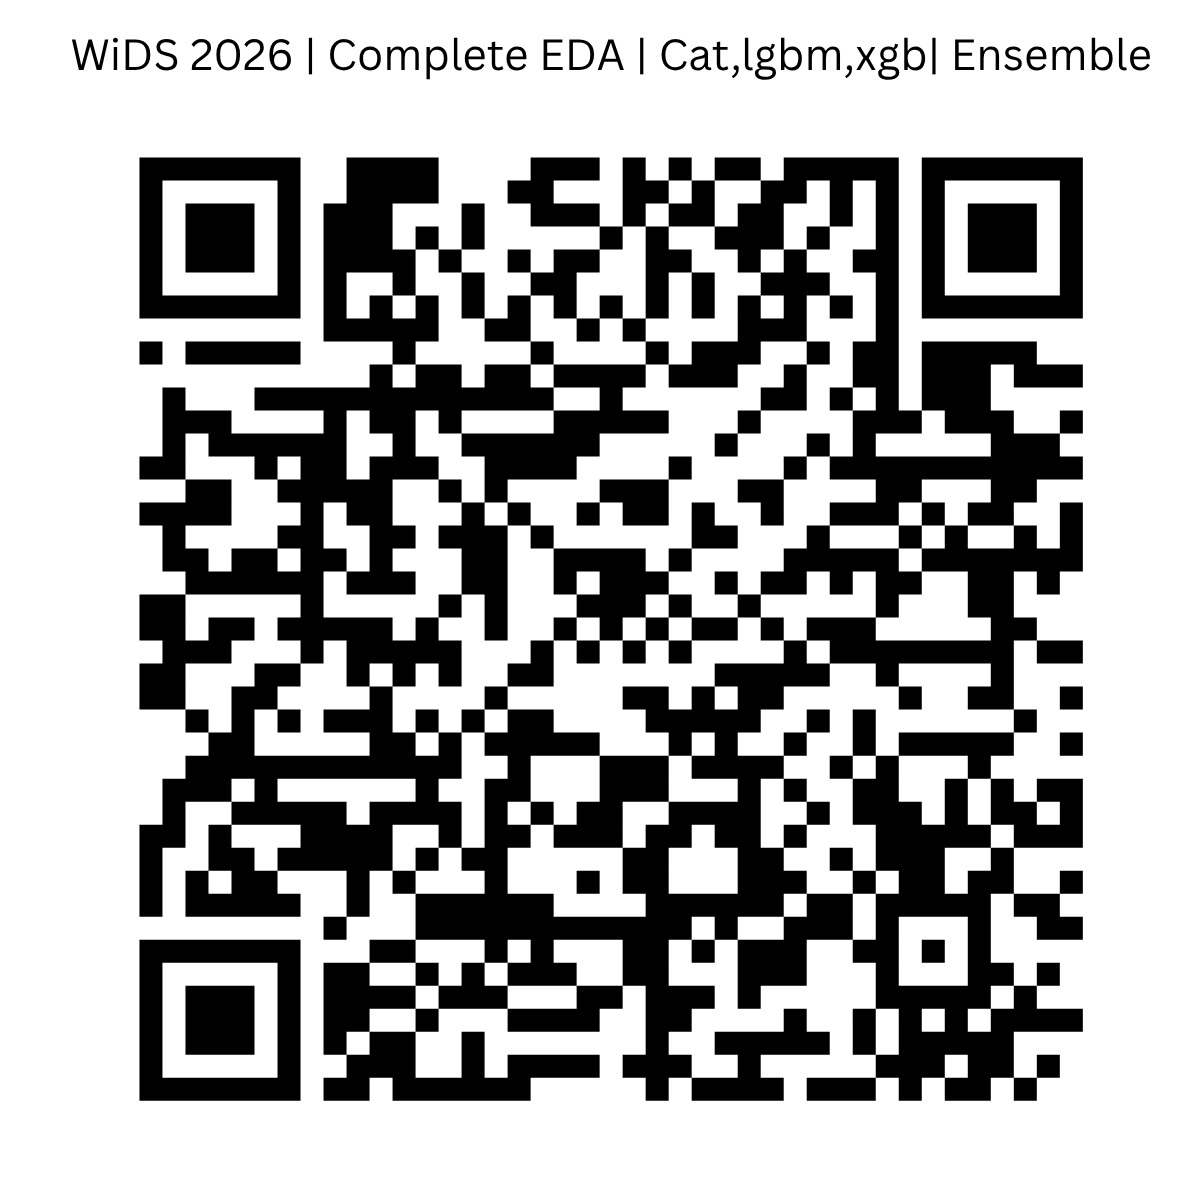

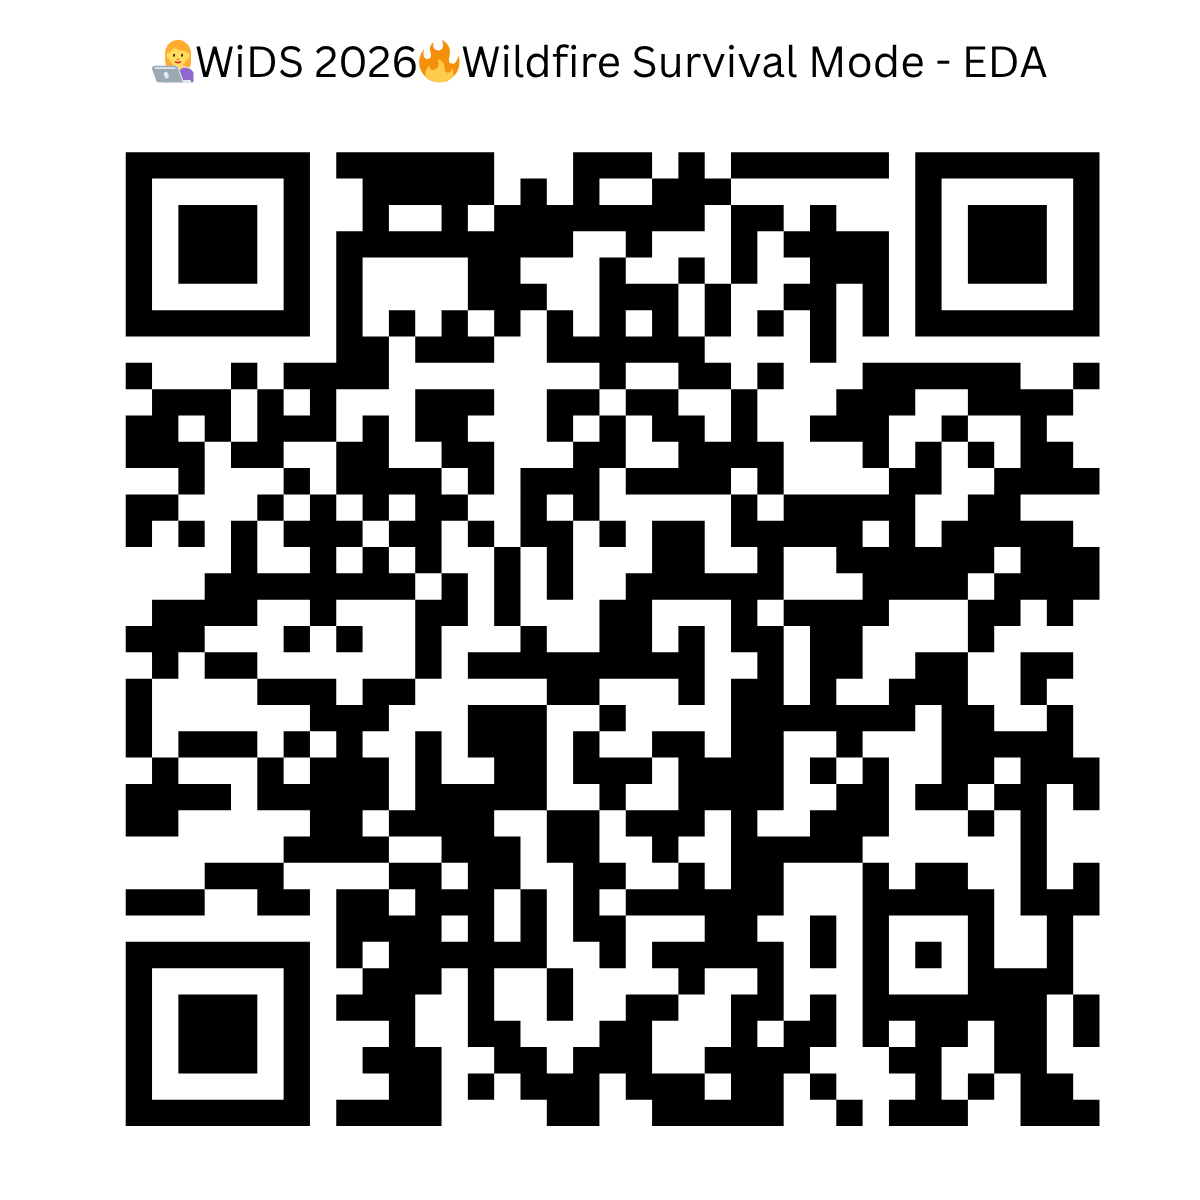

# Modelling & Evaluation

## Preparation:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Machine learning
from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier

# Try to import CatBoost (optional but helpful)
try:
    from catboost import CatBoostClassifier, Pool
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False



In [ ]:
# Load the datasets
train_raw = pd.read_csv("/content/drive/MyDrive/W in Data/Datathon/WiDSWorldWide_GlobalDathon26/train.csv")
test_raw = pd.read_csv("/content/drive/MyDrive/W in Data/Datathon/WiDSWorldWide_GlobalDathon26/test.csv")

In [ ]:
# Load the datasets
train_raw = pd.read_csv("./data/train.csv")
test_raw = pd.read_csv("./data/test.csv")

In [ ]:
# =============================================================
# CONFIGURATION - Change these settings as needed
# =============================================================

SEED = 42                      # Random seed for reproducibility
N_FOLDS = 5                    # Number of cross-validation folds
HORIZONS = [12, 24, 48, 72]    # Prediction time horizons (hours)
USE_GPU = True             # Set True if using GPU
CALIBRATE = True               # Apply isotonic calibration

# Set random seed
np.random.seed(SEED)

# =============================================================
# CHART STYLING - Professional dark theme
# =============================================================

# Colors that work well on both dark and light backgrounds
BACKGROUND = '#0f1117'
CARD_BG = '#161b22'
TEXT_COLOR = '#e6edf3'
MUTED_COLOR = '#7d8590'
GRID_COLOR = '#21262d'

# Fire-themed colors for our charts
FIRE_COLORS = ['#ff6b35', '#ff3333', '#ffcc02', '#ff8c42']
HIT_COLOR = '#ff4444'      # Red for fires that hit
MISS_COLOR = '#58a6ff'     # Blue for fires that missed
SAFE_COLOR = '#3fb950'     # Green for safe zones

# Apply the style to all charts
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': CARD_BG,
    'axes.edgecolor': GRID_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'axes.titlepad': 14,
    'text.color': TEXT_COLOR,
    'xtick.color': MUTED_COLOR,
    'ytick.color': MUTED_COLOR,
    'grid.color': GRID_COLOR,
    'grid.alpha': 0.35,
    'axes.grid': True,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'legend.facecolor': CARD_BG,
    'legend.edgecolor': GRID_COLOR,
})

print("Configuration complete!")
print(f"  Random seed: {SEED}")
print(f"  Cross-validation folds: {N_FOLDS}")
print(f"  Prediction horizons: {HORIZONS} hours")
print(f"  GPU mode: {USE_GPU}")
print(f"  Calibration: {CALIBRATE}")

In [ ]:
# def engineer_features(df):
#     """
#     Create physics-based features for wildfire prediction.

#     Args:
#         df: DataFrame with raw features

#     Returns:
#         DataFrame with original + new features
#     """
#     out = df.copy()

#     # Get key raw features
#     distance = out['dist_min_ci_0_5h'].clip(lower=1)  # Avoid division by zero
#     speed = out['closing_speed_m_per_h']

#     # Feature 1: Estimated time to contact
#     # Simple physics: time = distance / speed
#     # This tells us "at current speed, when will the fire reach the zone?"
#     out['time_to_contact'] = distance / speed.clip(lower=0.01)
#     out['log_time_to_contact'] = np.log1p(out['time_to_contact'].clip(0, 5000))

#     # Feature 2: Danger vector
#     # Combines alignment (is fire heading toward zone?) with speed
#     # High value = fire is moving fast AND heading straight at the zone
#     out['danger_vector'] = out['alignment_abs'] * speed

#     # Feature 3: Tracking urgency
#     # More perimeter observations + faster movement = more urgent situation
#     out['tracking_urgency'] = out['num_perimeters_0_5h'] * speed

#     # Feature 4: Fire intensity
#     # Growth rate * observation count = how aggressively is this fire behaving?
#     out['fire_intensity'] = out['area_growth_rate_ha_per_h'] * out['num_perimeters_0_5h']

#     # Feature 5: Approach momentum
#     # Combines speed, alignment, and proximity into one "danger score"
#     out['approach_momentum'] = speed * out['alignment_abs'] / np.log1p(distance)

#     # Feature 6: Log distance (tree models like log-transformed distances)
#     out['log_dist'] = np.log1p(distance)

#     # Feature 7-8: Distance zones (categorical approach)
#     # Critical zone: Very close, high danger
#     out['dist_zone_critical'] = (distance < 5000).astype(np.float32)
#     # Mid zone: Moderate distance, needs monitoring
#     out['dist_zone_mid'] = ((distance >= 5000) & (distance < 15000)).astype(np.float32)

#     # Feature 9: Speed per unit distance (normalized approach rate)
#     out['speed_per_km'] = speed / (distance / 1000).clip(lower=0.1)

#     # Clean up any infinite or NaN values
#     out = out.replace([np.inf, -np.inf], np.nan).fillna(0)

#     return out

# # Apply feature engineering to both datasets
# train_fe = engineer_features(train_raw)
# test_fe = engineer_features(test_raw)

# # Get final feature list
# feature_cols = [c for c in train_fe.columns
#                 if c not in ['event_id', 'event', 'time_to_hit_hours']]

In [ ]:
# Final features for ML (Your 15 + the 6 new ones)
feature_cols = [
    # Your Core Growth
    'area_first_ha', 'area_growth_abs_0_5h', 'log1p_area_first',
    # Your Core Distance
    'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
    'dist_slope_ci_0_5h', 'dist_accel_m_per_h2', 'closing_speed_abs_m_per_h',
    # Your Core Directionality
    'alignment_cos', 'along_track_speed', 'cross_track_component',
    'alignment_abs', 'spread_bearing_deg', 'spread_bearing_sin',
    # Your Core Kinematics
    'centroid_speed_m_per_h',
    # The New Physics Features
    'time_to_contact', 'danger_vector', 'fire_intensity',
    'approach_momentum', 'dist_zone_critical', 'speed_per_km'
]

Targets

In [ ]:
def build_survival_targets(time_values, event_values, horizons):
    """
    Build censoring-aware binary targets for each time horizon.

    Args:
        time_values: Array of time-to-hit values
        event_values: Array of event indicators (1=hit, 0=censored)
        horizons: List of time horizons to predict

    Returns:
        targets: Dictionary of target arrays per horizon
        masks: Dictionary of valid sample masks per horizon
    """
    targets = {}
    masks = {}

    for H in horizons:
        # Find samples where outcome is unknown
        # (censored before the horizon, so we cannot know if they would have hit)
        unknown = (event_values == 0) & (time_values < H)

        # Create target: 1 if hit by time H, 0 otherwise
        y = ((event_values == 1) & (time_values <= H)).astype(np.float64)

        # Mark unknown outcomes as NaN (will be excluded from training)
        y[unknown] = np.nan

        targets[H] = y
        masks[H] = ~unknown  # True = valid sample, False = exclude

    return targets, masks

# Extract time and event arrays
time_arr = train_fe['time_to_hit_hours'].values
event_arr = train_fe['event'].values.astype(int)

# Build targets for all horizons
train_targets, train_masks = build_survival_targets(time_arr, event_arr, HORIZONS)

# Print summary
print("Censoring-aware targets created!")
print()
print("Valid samples per horizon:")
print("-" * 55)
print(f"{'Horizon':<10} {'Total':<10} {'Positives':<12} {'Negatives':<12} {'Excluded':<10}")
print("-" * 55)

for H in HORIZONS:
    n_valid = int(train_masks[H].sum())
    n_pos = int(np.nansum(train_targets[H]))
    n_neg = n_valid - n_pos
    n_excluded = len(train_fe) - n_valid
    print(f"{H}h{'':<7} {n_valid:<10} {n_pos:<12} {n_neg:<12} {n_excluded:<10}")

print("-" * 55)
print()
print("Notice how the 72h horizon has fewer valid samples?")
print("That is because many fires were censored before 72 hours.")

## Define Evaluation Metrics
The competition uses a **Hybrid Score** that combines two metrics:

### Concordance Index (C-Index): 30% weight
Measures how well we RANK fires by urgency. If Fire A hits before Fire B, does our model give Fire A a higher risk score?

- Score of 0.5 = random guessing
- Score of 1.0 = perfect ranking
- Higher is better!

### Brier Score: 70% weight
Measures how CALIBRATED our probabilities are. If we say 80% probability, do 80% of those fires actually hit?

- Score of 0.0 = perfect calibration
- Score of 0.25 = random guessing
- Lower is better!

### The Hybrid Formula
`Hybrid Score = 0.3 * C-Index + 0.7 * (1 - Weighted Brier)`
Where Weighted Brier gives more importance to the 48h horizon:

`Weighted Brier = 0.3 * Brier@24h + 0.4 * Brier@48h + 0.3 * Brier@72h`
Why 48h? Because 24-48 hours is the sweet spot for emergency planning. Enough time to act, but urgent enough to matter.


In [ ]:
def c_index(time, event, risk):
    """
    Calculate the concordance index (C-Index).

    Measures how well the risk scores rank fires by time-to-event.
    For every pair of fires where one hit before the other,
    check if the earlier fire has higher risk.
    """
    t = np.asarray(time, dtype=float)
    e = np.asarray(event, dtype=int)
    r = np.asarray(risk, dtype=float)

    n = len(t)
    concordant = 0.0
    tied = 0.0
    comparable = 0.0

    for i in range(n):
        if e[i] != 1:  # Only compare when fire i actually hit
            continue
        for j in range(n):
            if i == j or t[i] >= t[j]:  # Fire i must hit before j
                continue
            comparable += 1.0
            if r[i] > r[j]:
                concordant += 1.0
            elif r[i] == r[j]:
                tied += 1.0

    if comparable == 0:
        return 0.5
    return (concordant + 0.5 * tied) / comparable


def brier_at(time, event, prob, H):
    """
    Calculate censoring-aware Brier score at horizon H.

    Excludes samples that were censored before time H
    (because their true outcome is unknown).
    """
    t = np.asarray(time, dtype=float)
    e = np.asarray(event, dtype=int)
    p = np.clip(np.asarray(prob, dtype=float), 0, 1)

    # Valid samples: not censored before H
    valid = ~((e == 0) & (t < H))

    if valid.sum() == 0:
        return 0.25  # Return baseline if no valid samples

    # True labels: did fire hit by time H?
    y_true = ((e == 1) & (t <= H)).astype(float)[valid]

    # Brier score = mean squared error
    return float(np.mean((p[valid] - y_true) ** 2))


def hybrid_score(time, event, p24, p48, p72, risk=None):
    """
    Calculate the competition hybrid metric.

    Hybrid = 0.3 * C-Index + 0.7 * (1 - Weighted Brier)
    """
    # Use average probability as risk score if not provided
    if risk is None:
        risk = 0.3 * p24 + 0.4 * p48 + 0.3 * p72

    # Calculate C-Index
    ci = c_index(time, event, risk)

    # Calculate weighted Brier
    b24 = brier_at(time, event, p24, 24)
    b48 = brier_at(time, event, p48, 48)
    b72 = brier_at(time, event, p72, 72)
    weighted_brier = 0.3 * b24 + 0.4 * b48 + 0.3 * b72

    # Combine into hybrid score
    hybrid = 0.3 * ci + 0.7 * (1 - weighted_brier)

    return hybrid, ci, weighted_brier


def enforce_monotonicity(probs):
    """
    Ensure probabilities increase over time.

    It does not make sense for P(hit by 48h) < P(hit by 24h).
    This function fixes any violations.
    """
    out = np.clip(probs.copy(), 0, 1)
    for i in range(1, out.shape[1]):
        out[:, i] = np.maximum(out[:, i], out[:, i - 1])
    return out


print("Evaluation metrics defined!")
print()
print("Quick test with random predictions:")
test_probs = np.random.rand(len(train_fe))
score, ci, wb = hybrid_score(time_arr, event_arr, test_probs, test_probs, test_probs)
print(f"  Random predictions: Hybrid={score:.4f}, C-Index={ci:.4f}, W-Brier={wb:.4f}")
print()
print("(A good model should score much higher than random!)")

## Modelling
### Train the Models
Now for the main event: training our ensemble of models!

### Why Use Multiple Models?
Different gradient boosting frameworks have slightly different:

- Splitting strategies
- Regularization methods
- Handling of numerical precision
By combining predictions from multiple models, we reduce the chance of any single model's quirks hurting our score.

### Our Ensemble
1) LightGBM: Very fast, good with sparse features
2) XGBoost: Strong regularization, industry standard
3) CatBoost: Great at preventing overfitting (if available)

### Training Strategy
- 5-Fold Cross-Validation: Train 5 times, each time holding out 20% for validation
- Early Stopping: Stop training when validation score stops improving
- Conservative Parameters: With only 221 training samples, we need to prevent overfitting

In [ ]:
# Prepare data matrices
X = train_fe[feature_cols].values.astype(np.float32)
X_test = test_fe[feature_cols].values.astype(np.float32)

# Model hyperparameters (tuned for small dataset)
lgb_params = dict(
    objective='binary',
    learning_rate=0.035,
    num_leaves=15,
    max_depth=3,
    min_child_samples=25,
    subsample=0.80,
    colsample_bytree=0.70,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_estimators=800,
    random_state=SEED,
    verbose=-1,
    n_jobs=-1,
)

xgb_params = dict(
    objective='binary:logistic',
    learning_rate=0.035,
    max_depth=3,
    min_child_weight=25,
    subsample=0.80,
    colsample_bytree=0.70,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_estimators=800,
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
    tree_method='gpu_hist' if USE_GPU else 'hist',
    eval_metric='logloss',
)

cat_params = dict(
    iterations=800,
    learning_rate=0.035,
    depth=3,
    l2_leaf_reg=3.0,
    random_seed=SEED,
    verbose=0,
    task_type='GPU' if USE_GPU else 'CPU',
    eval_metric='Logloss',
)

if USE_GPU:
    lgb_params['device'] = 'gpu'

# Setup cross-validation
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage for predictions and metrics
oof_preds = np.full((len(train_fe), len(HORIZONS)), np.nan)
test_preds = np.zeros((len(test_fe), len(HORIZONS)))
fold_scores = []
importances = []

# Print header
print("=" * 70)
print("TRAINING PROGRESS")
print("=" * 70)
header = f"{'Fold':<6}{'Hybrid':>10}{'C-Index':>10}{'W-Brier':>10}{'B@24':>9}{'B@48':>9}{'B@72':>9}"
print(header)
print("-" * 70)

# Train across folds
for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X, event_arr)):
    fold_test = np.zeros((len(test_fe), len(HORIZONS)))
    fold_imp = np.zeros(len(feature_cols))

    # Train a model for each time horizon
    for h_i, H in enumerate(HORIZONS):
        y_full = train_targets[H]
        y_tr = y_full[tr_idx]
        y_va = y_full[va_idx]

        # Find valid samples (not NaN)
        tr_ok = ~np.isnan(y_tr)
        va_ok = ~np.isnan(y_va)

        # Skip if not enough data
        if tr_ok.sum() < 5 or va_ok.sum() < 3:
            fallback = float(np.nanmean(y_full[~np.isnan(y_full)]))
            oof_preds[va_idx, h_i] = fallback
            fold_test[:, h_i] += fallback
            continue

        Xtr, ytr = X[tr_idx][tr_ok], y_tr[tr_ok]
        Xva, yva = X[va_idx][va_ok], y_va[va_ok]

        # Check for single-class edge case
        unique_classes = np.unique(ytr)
        if len(unique_classes) < 2:
            fallback = float(unique_classes[0])
            oof_preds[va_idx, h_i] = fallback
            fold_test[:, h_i] += fallback
            continue

        preds_va = np.zeros(len(va_idx))
        preds_te = np.zeros(len(test_fe))
        models_trained = 0

        # Train LightGBM
        try:
            m_lgb = LGBMClassifier(**lgb_params)
            m_lgb.fit(
                Xtr, ytr,
                eval_set=[(Xva, yva)],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(0)
                ]
            )
            preds_va += m_lgb.predict_proba(X[va_idx])[:, 1]
            preds_te += m_lgb.predict_proba(X_test)[:, 1]
            fold_imp += m_lgb.feature_importances_
            models_trained += 1
        except Exception:
            pass

        # Train XGBoost
        try:
            m_xgb = XGBClassifier(**xgb_params)
            m_xgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
            preds_va += m_xgb.predict_proba(X[va_idx])[:, 1]
            preds_te += m_xgb.predict_proba(X_test)[:, 1]
            models_trained += 1
        except Exception:
            pass

        # Train CatBoost (if available)
        if HAS_CATBOOST:
            try:
                m_cat = CatBoostClassifier(**cat_params)
                m_cat.fit(
                    Pool(Xtr, ytr),
                    eval_set=Pool(Xva, yva),
                    early_stopping_rounds=50
                )
                preds_va += m_cat.predict_proba(X[va_idx])[:, 1]
                preds_te += m_cat.predict_proba(X_test)[:, 1]
                models_trained += 1
            except Exception:
                pass

        # Average predictions across models
        if models_trained > 0:
            preds_va /= models_trained
            preds_te /= models_trained
            oof_preds[va_idx, h_i] = preds_va
            fold_test[:, h_i] = preds_te
        else:
            fallback = float(np.mean(ytr))
            oof_preds[va_idx, h_i] = fallback
            fold_test[:, h_i] = fallback

    # Enforce monotonicity and accumulate predictions
    fold_oof = enforce_monotonicity(oof_preds[va_idx].copy())
    oof_preds[va_idx] = fold_oof
    fold_test = enforce_monotonicity(fold_test)
    test_preds += fold_test / N_FOLDS
    importances.append(fold_imp / len(HORIZONS))

    # Calculate fold metrics
    t_va, e_va = time_arr[va_idx], event_arr[va_idx]
    score, ci, wb = hybrid_score(t_va, e_va, fold_oof[:, 1], fold_oof[:, 2], fold_oof[:, 3])
    b24 = brier_at(t_va, e_va, fold_oof[:, 1], 24)
    b48 = brier_at(t_va, e_va, fold_oof[:, 2], 48)
    b72 = brier_at(t_va, e_va, fold_oof[:, 3], 72)
    fold_scores.append(score)

    print(f"  {fold_i + 1:<4}{score:10.4f}{ci:10.4f}{wb:10.4f}{b24:9.4f}{b48:9.4f}{b72:9.4f}")

print("-" * 70)
mean_score = np.mean(fold_scores)
std_score = np.std(fold_scores)
print(f"  Mean{mean_score:10.4f} +/- {std_score:.4f}")
print("=" * 70)

# Analyze Results
Let us visualize how well our model performed!

## Cross-Validation Scores
Each fold shows how well the model performed on held-out data. Consistent scores across folds mean our model is stable.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Create bar chart
bars = ax.bar(
    range(1, N_FOLDS + 1),
    fold_scores,
    color=FIRE_COLORS[0],
    alpha=0.85,
    edgecolor='none',
    width=0.5
)

# Add mean line
ax.axhline(
    np.mean(fold_scores),
    color=FIRE_COLORS[2],
    ls='--',
    lw=2,
    label=f'Mean: {np.mean(fold_scores):.4f}'
)

# Add score labels on bars
for bar, score in zip(bars, fold_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.002,
        f'{score:.4f}',
        ha='center',
        color=TEXT_COLOR,
        fontsize=11
    )

ax.set_xlabel('Fold')
ax.set_ylabel('Hybrid Score')
ax.set_title('Cross-Validation Hybrid Scores by Fold')
ax.set_ylim(min(fold_scores) - 0.03, max(fold_scores) + 0.02)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Score range: {min(fold_scores):.4f} to {max(fold_scores):.4f}")
print(f"Standard deviation: {np.std(fold_scores):.4f}")
print()
if np.std(fold_scores) < 0.02:
    print("Low variance across folds = stable model!")
else:
    print("Note: Some variance across folds (normal for small datasets)")

## Test Prediction Distributions
What do our final predictions look like? A good distribution should have:

- Clear separation between low and high risk fires
- Full use of the probability range (not all clustered at 0.5)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (H, ax) in enumerate(zip(HORIZONS, axes)):
    ax.hist(
        test_preds[:, i],
        bins=25,
        color=FIRE_COLORS[i % len(FIRE_COLORS)],
        alpha=0.85,
        edgecolor='none'
    )
    ax.set_title(f'prob_{H}h')
    ax.set_xlabel('Probability')
    ax.set_ylabel('Count')
    ax.set_xlim(-0.05, 1.05)

    # Add median line
    med = np.median(test_preds[:, i])
    ax.axvline(med, color=TEXT_COLOR, ls=':', lw=1.5, alpha=0.7)
    ax.text(med + 0.03, ax.get_ylim()[1] * 0.85, f'median={med:.3f}',
            color=TEXT_COLOR, fontsize=9)

plt.suptitle('Test Prediction Distributions', fontsize=14, fontweight='bold', color=TEXT_COLOR, y=1.02)
plt.tight_layout()
plt.show()

print("Distribution statistics:")
for i, H in enumerate(HORIZONS):
    print(f"  {H}h: min={test_preds[:, i].min():.3f}, "
          f"median={np.median(test_preds[:, i]):.3f}, "
          f"max={test_preds[:, i].max():.3f}")

## The complete Kaggle Notebok can be found below:

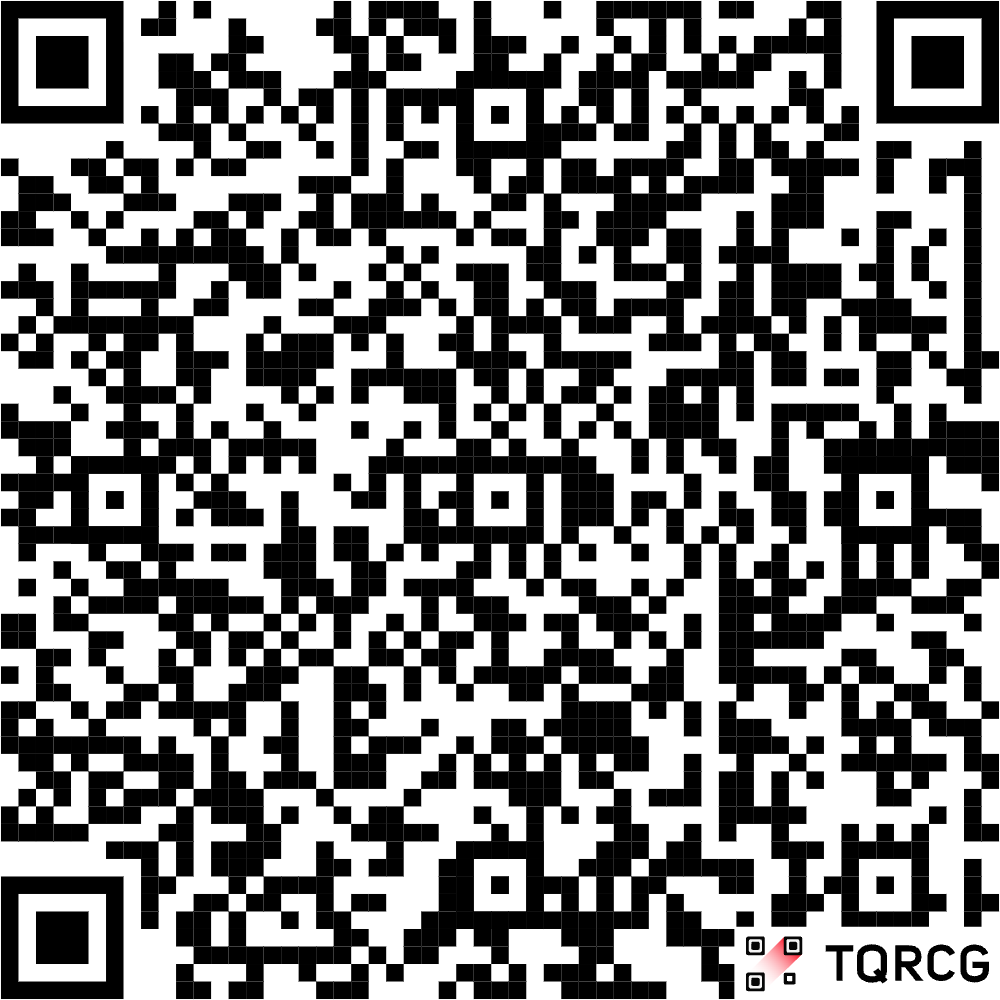